In [193]:
import numpy as np
import matplotlib.pyplot as plt
import json
import itertools

# load all data

data = {}

concurrency_counts = list(reversed(['0', '1', '2']))
time_lengths = ['500', '750', '1000']
browsers = ['operagx', 'chrome']
browsers_pretty = ['Opera GX', 'Google Chrome']
adblock_enabled = ['false', 'true']

for count, time, browser, adblocker in itertools.product(concurrency_counts, time_lengths, browsers, adblock_enabled):
    filepath = f'data/{count}con-{time}ms-data/{browser}-{adblocker}-times.json'
    with open(filepath, 'r') as file:
        file_data = np.mean(np.array(list(json.load(file).values())), axis=1)
    data[(count, time, browser, adblocker)] = file_data

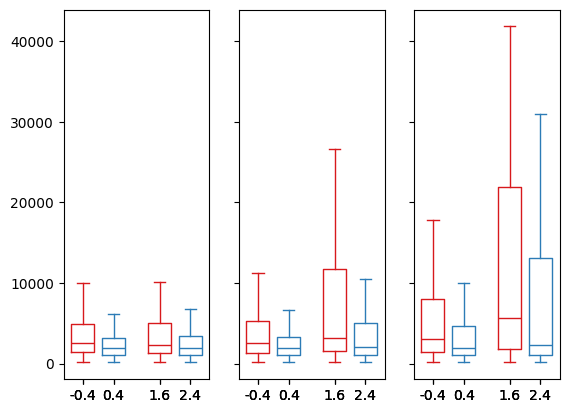

In [118]:
# Box and whisker plots

fig, axs = plt.subplots(ncols=3, sharex=True, sharey=True)

def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)
    plt.setp(bp['medians'], color=color)

for x in range(len(concurrency_counts)):
    plot = axs[x]
    count = concurrency_counts[x]
    ads = [np.mean(np.array(list(data[(count, time, browser, 'false')] for time in time_lengths)), axis=0) for browser in browsers]
    no_ads = [np.mean(np.array(list(data[(count, time, browser, 'true')] for time in time_lengths)), axis=0) for browser in browsers]
    

    bpl = plot.boxplot(ads, sym='', positions=np.array(range(len(ads)))*2.0-0.4, widths=0.6)
    bpr = plot.boxplot(no_ads, sym='', positions=np.array(range(len(no_ads)))*2.0+0.4, widths=0.6)
    set_box_color(bpl, '#D7191C') # colors are from http://colorbrewer2.org/
    set_box_color(bpr, '#2C7BB6')
    


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_ads = [data[('1','750','operagx','false')], data[('1','750','chrome','false')]]
data_no_ads = [data[('1','750','operagx','true')], data[('1','750','chrome','true')]]

ticks = browsers_pretty

def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)
    plt.setp(bp['medians'], color=color)

plt.figure()
mult = 2.0
delt = 0.4
bpl = plt.violinplot(data_ads, positions=np.array(range(len(data_ads)))*mult-delt, widths=0.6)
bpr = plt.violinplot(data_no_ads, positions=np.array(range(len(data_no_ads)))*mult+delt, widths=0.6, showmedians=True, showextrema=True)
# set_box_color(bpl, '#D7191C') # colors are from http://colorbrewer2.org/
# set_box_color(bpr, '#2C7BB6')

# draw temporary red and blue lines and use them to create a legend
plt.plot([], c='#D7191C', label='Ads')
plt.plot([], c='#2C7BB6', label='No Ads')
plt.legend()

plt.xticks(range(0, len(ticks) * 2, 2), ticks)
plt.xlim(-2, len(ticks)*2)
plt.ylabel('Time Until Network Idle (ms)')
plt.xlabel('Browser')
plt.title('Box and Whisker Plot of Time Until Network Idle')
plt.tight_layout()
plt.savefig('boxcompare.png')

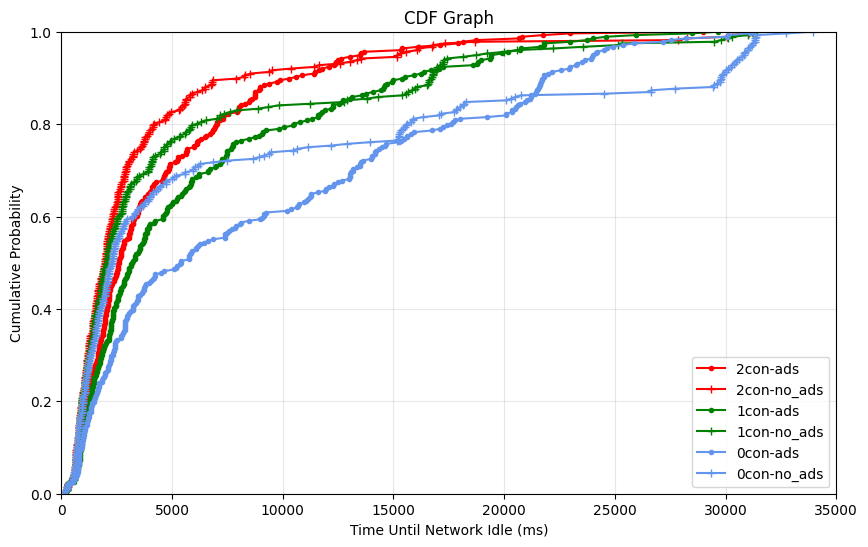

In [ ]:
plt.figure(figsize=(10,6))
mkrs = {'true':'+', 'false':'.'}
colors = {'0':'cornflowerblue', '1':'g', '2':'r'}
for count, adblocker in itertools.product(concurrency_counts, adblock_enabled):
    arr = np.mean(np.array(list(data[(count, time, browser, adblocker)] for time, browser in itertools.product(time_lengths, browsers))), axis=0)
    sorted_data = np.sort(arr)
    n = len(arr)
    y = np.arange(1, n + 1) / n
    plt.plot(sorted_data, y, marker=mkrs[adblocker], linestyle='-', color=colors[count], label=f'{count}con-{"no_ads" if adblocker == "true" else "ads"}')

# 4. Add labels, title, legend, and grid
plt.title("CDF of Time Until Network Idle")
plt.xlabel("Time Until Network Idle (ms)")
plt.xlim(0,35000)
plt.ylabel("Cumulative Probability")
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.legend()  # Add a legend to distinguish the lines
plt.savefig('cdf-merge_browsers_and_times.png')
plt.show()

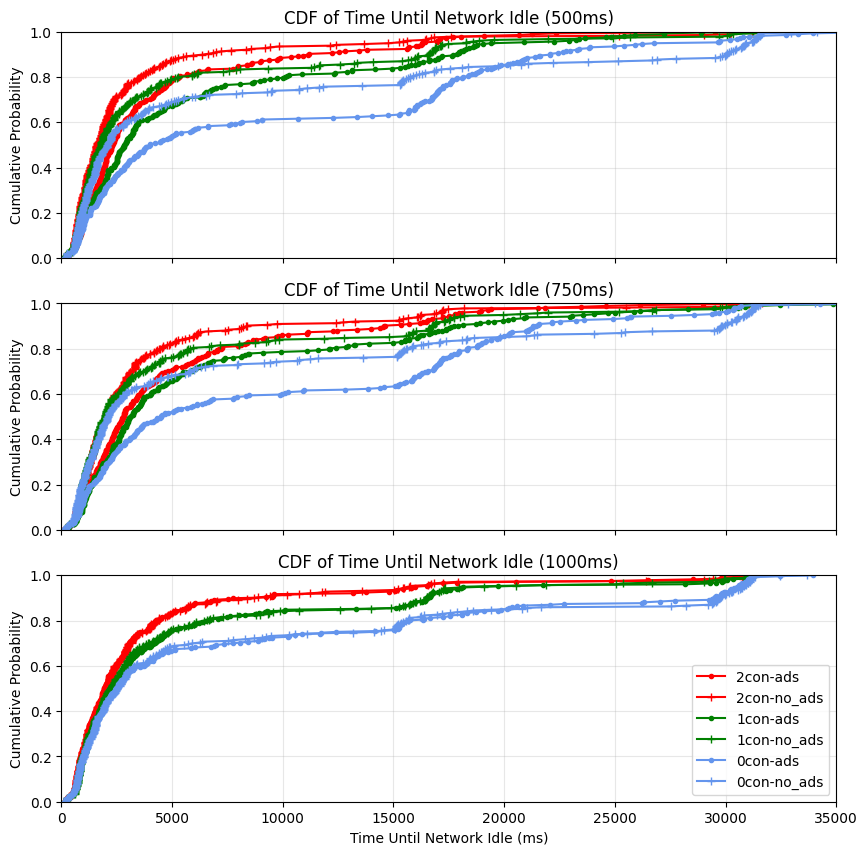

In [206]:
fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True)
fig.set_size_inches((10,10))
mkrs = {'true':'+', 'false':'.'}
colors = {'0':'cornflowerblue', '1':'g', '2':'r'}

for ypos in range(len(time_lengths)):
    plot = axs[ypos]
    time = time_lengths[ypos]
    for count, adblocker in itertools.product(concurrency_counts, adblock_enabled):
        arr = np.mean(np.array(list(data[(count, time, browser, adblocker)] for browser in browsers)), axis=0)
        sorted_data = np.sort(arr)
        n = len(arr)
        y = np.arange(1, n + 1) / n
        plot.plot(sorted_data, y, marker=mkrs[adblocker], linestyle='-', color=colors[count], label=f'{count}con-{"no_ads" if adblocker == "true" else "ads"}')
    plot.grid(True, alpha=0.3)
    plot.set_title(f'CDF of Time Until Network Idle ({time}ms)')
    plot.set_ylabel('Cumulative Probability')

# 4. Add labels, title, legend, and grid
plt.xlim(0,35000)
plt.xlabel("Time Until Network Idle (ms)")
plt.ylim(0,1)
plt.legend()  # Add a legend to distinguish the lines
plt.savefig('cdf-merged_browsers.png')
plt.show()

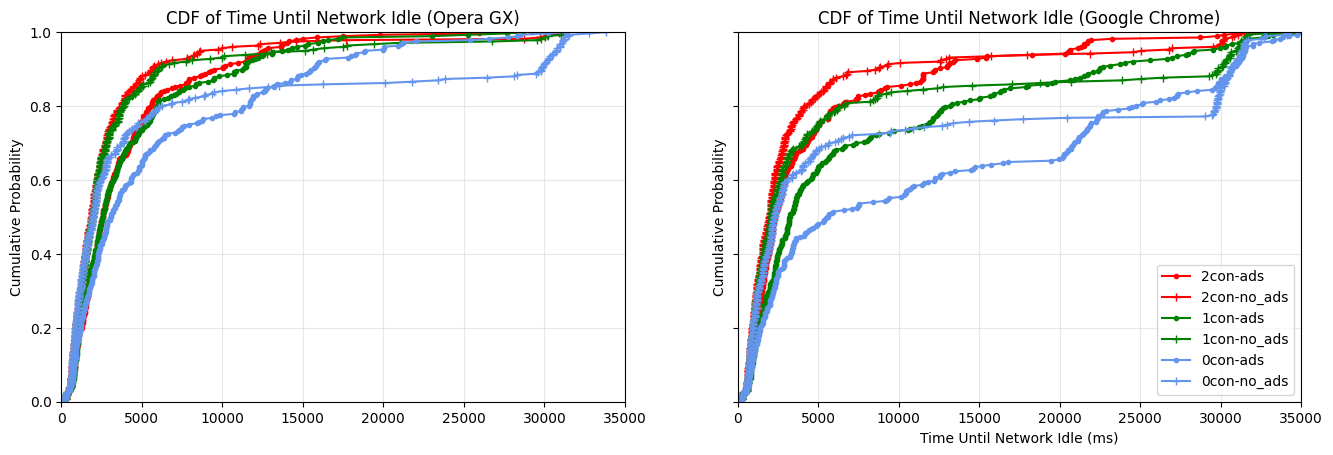

In [207]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)
fig.set_size_inches((16,4.8))
mkrs = {'true':'+', 'false':'.'}
colors = {'0':'cornflowerblue', '1':'g', '2':'r'}

for xpos in range(len(browsers)):
    plot = axs[xpos]
    browser = browsers[xpos]
    for count, adblocker in itertools.product(concurrency_counts, adblock_enabled):
        arr = np.mean(np.array(list(data[(count, time, browser, adblocker)] for time in time_lengths)), axis=0)
        sorted_data = np.sort(arr)
        n = len(arr)
        y = np.arange(1, n + 1) / n
        plot.plot(sorted_data, y, marker=mkrs[adblocker], linestyle='-', color=colors[count], label=f'{count}con-{"no_ads" if adblocker == "true" else "ads"}')
    plot.grid(True, alpha=0.3)
    plot.set_title(f'CDF of Time Until Network Idle ({"Opera GX" if browser == "operagx" else "Google Chrome"})')
    plot.set_ylabel('Cumulative Probability')

# 4. Add labels, title, legend, and grid
plt.xlim(0,35000)
plt.xlabel("Time Until Network Idle (ms)")
plt.ylim(0,1)
plt.legend()  # Add a legend to distinguish the lines
plt.savefig('cdf-merged_times.png')
plt.show()

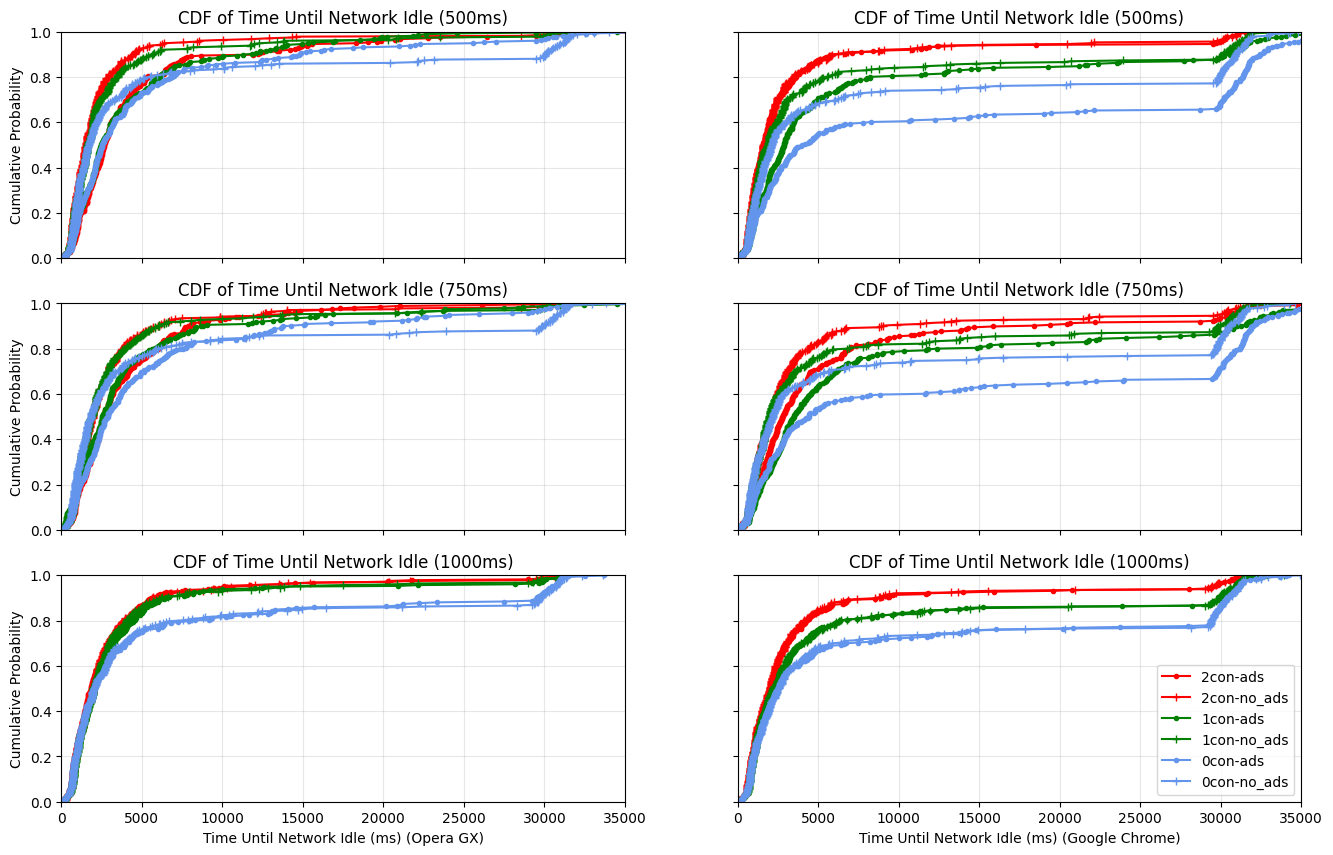

In [204]:
fig, axs = plt.subplots(3,2, sharex=True, sharey=True)
fig.set_size_inches((16,10))
mkrs = {'true':'+', 'false':'.'}
colors = {'0':'cornflowerblue', '1':'g', '2':'r'}

for xpos in range(len(browsers)):
    browser = browsers[xpos]
    for ypos in range(len(time_lengths)):
        plot = axs[ypos,xpos]
        time = time_lengths[ypos]
        for count, adblocker in itertools.product(concurrency_counts, adblock_enabled):
            arr = data[(count, time, browser, adblocker)]
            sorted_data = np.sort(arr)
            n = len(arr)
            y = np.arange(1, n + 1) / n
            plot.plot(sorted_data, y, marker=mkrs[adblocker], linestyle='-', color=colors[count], label=f'{count}con-{"no_ads" if adblocker == "true" else "ads"}')
        plot.grid(True, alpha=0.3)
        plot.set_title(f'CDF of Time Until Network Idle ({time}ms)')
        if (xpos == 0):
            plot.set_ylabel('Cumulative Probability')
    plot.set_xlabel(f'Time Until Network Idle (ms) ({"Opera GX" if browser == "operagx" else "Google Chrome"})')

# 4. Add labels, title, legend, and grid
plt.xlim(0,35000)
plt.ylim(0,1)
plt.legend()  # Add a legend to distinguish the lines
plt.savefig('cdf.png')
plt.show()